In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

In [3]:
df = pd.read_csv("Data/movies.csv")

df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB


(2000, 7)

## Data Cleaning

In [4]:
#1 Missing Values
df.isnull().sum()

budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64

In [5]:
# Remove Zero Budget/Revenue
df = df[(df['budget']>0) &
        (df['revenue']>0)]

In [6]:
# Create Target Variable
df['success'] = np.where(
    df['revenue']>df['budget'],
    1,
    0
)

In [7]:
# Success Percentage
df['success'].value_counts(normalize=True)*100

success
1    80.7
0    19.3
Name: proportion, dtype: float64

## Feature Engineering

Profit Column

In [8]:

df['profit']=df['revenue']-df['budget']

ROI

In [9]:

df['roi']=(
    df['profit']/df['budget']
)*100

## Process Genre Column

Success label

In [24]:

df["success_status"] = df["success"].map({
    1: "Successful",
    0: "Unsuccessful"
})

Main genre

In [25]:
df["main_genre"] = (
    df["genres"]
    .str.split("|")
    .str[0]
)

In [26]:
## Split them

df['genres']=df['genres'].fillna('Unknown')

In [28]:
print(df.columns.tolist())

['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'title', 'genres', 'success', 'profit', 'roi', 'success_status', 'main_genre']


In [29]:
df.head()

,budget,revenue,popularity,runtime,vote_average,title,genres,success,profit,roi,success_status,main_genre
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]",1,49568335,85.825130,Successful,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]",1,150796523,78.498967,Successful,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]",1,124684964,97.014594,Successful,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]",0,-66663914,-42.651389,Unsuccessful,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]",1,72601048,48.878792,Successful,"[{'id': 35, 'name': 'Comedy'}]"


In [19]:
df["success"] = (df["revenue"] > df["budget"]).astype(int)

In [20]:
df["success_status"] = df["success"].map({
    1: "Successful",
    0: "Unsuccessful"
})

In [21]:
df[["revenue", "budget", "success", "success_status"]].head()

,revenue,budget,success,success_status
0,107323371,57755036,1,Successful
1,342896533,192100010,1,Successful
2,253206827,128521863,1,Successful
3,89635602,156299516,0,Unsuccessful
4,221133868,148532820,1,Successful


## Exploratory Data Analysis


## Univariate Analysis

Budget Distribution

<Axes: xlabel='budget', ylabel='Count'>

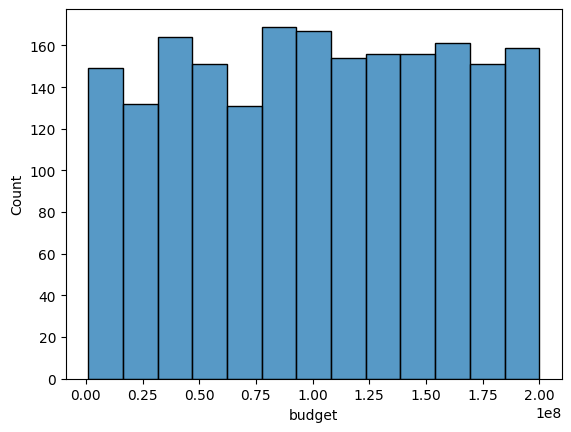

In [11]:
sns.histplot(df['budget'])

Revenue Distribution

<Axes: xlabel='revenue', ylabel='Count'>

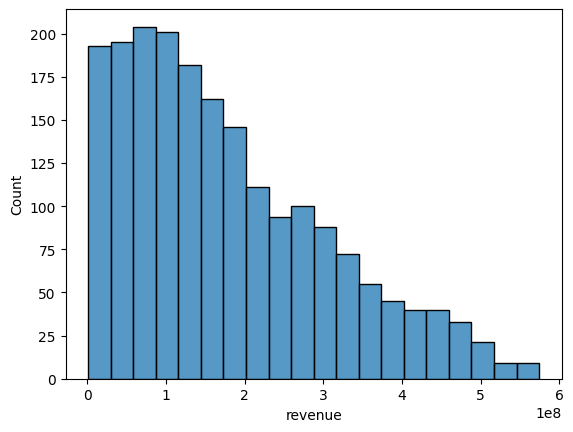

In [12]:
sns.histplot(df['revenue'])

Runtime Distribution

<Axes: xlabel='runtime', ylabel='Count'>

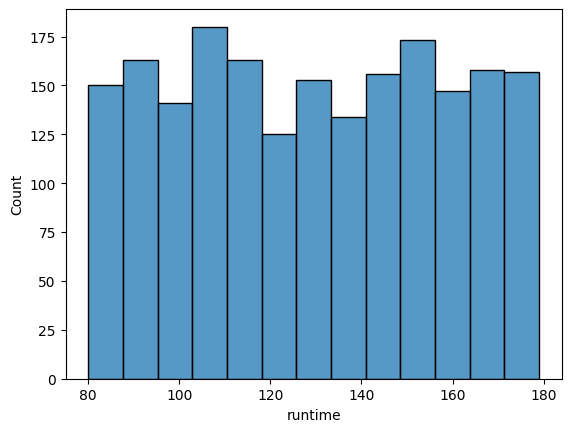

In [13]:
sns.histplot(df['runtime'])

Success Count

<Axes: xlabel='success', ylabel='count'>

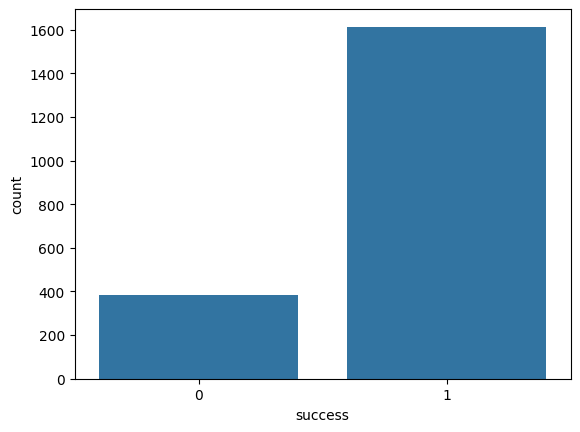

In [14]:

sns.countplot(
    x='success',
    data=df
)

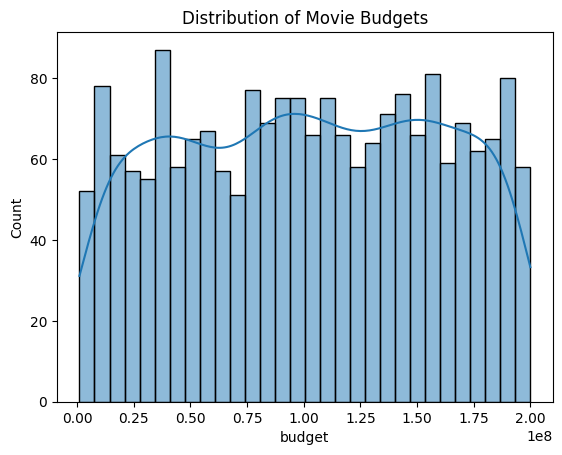

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["budget"], bins=30, kde=True)
plt.title("Distribution of Movie Budgets")
plt.show()

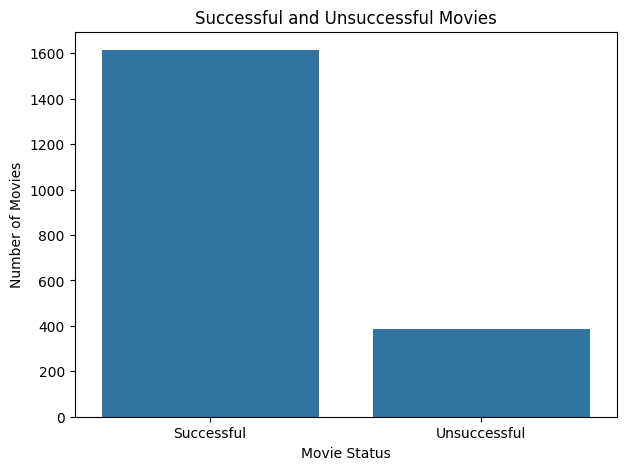

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="success_status",
    order=["Successful", "Unsuccessful"]
)

plt.title("Successful and Unsuccessful Movies")
plt.xlabel("Movie Status")
plt.ylabel("Number of Movies")
plt.show()

## Bivariate Analysis

Budget vs Revenue

<Axes: xlabel='budget', ylabel='revenue'>

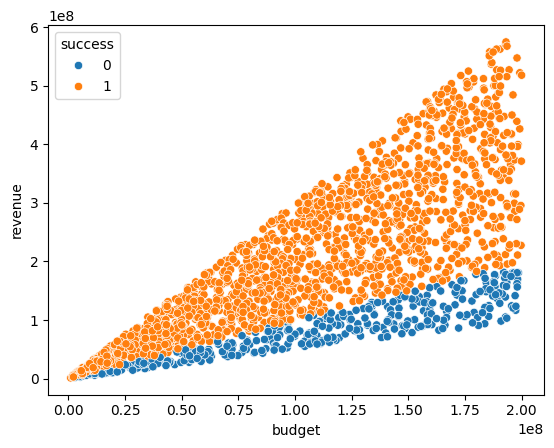

In [17]:


sns.scatterplot(
    x='budget',
    y='revenue',
    hue='success',
    data=df
)

Popularity vs Revenue

<Axes: xlabel='popularity', ylabel='revenue'>

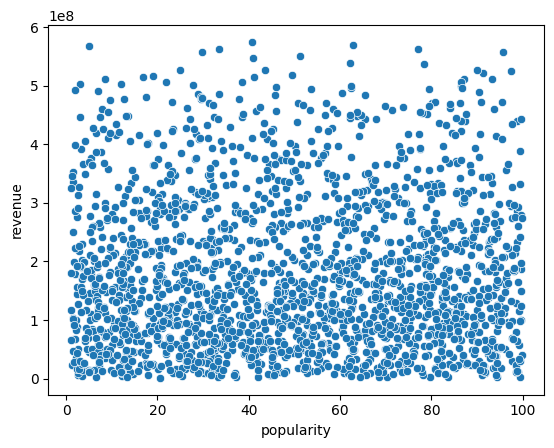

In [18]:
sns.scatterplot(
    x='popularity',
    y='revenue',
    data=df
)

Popularity versus success

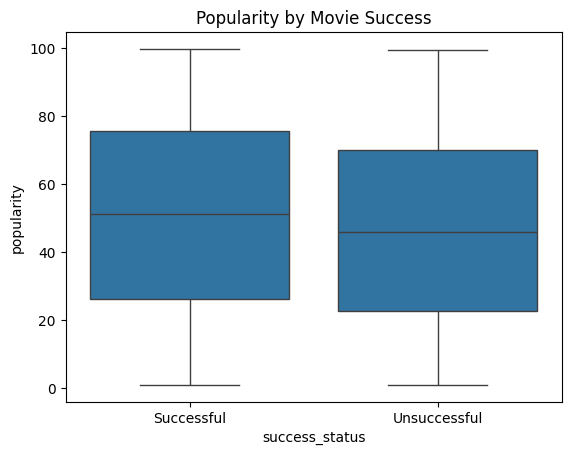

In [30]:
sns.boxplot(
    data=df,
    x="success_status",
    y="popularity"
)

plt.title("Popularity by Movie Success")
plt.show()

Vote Average vs Success

<Axes: xlabel='success', ylabel='vote_average'>

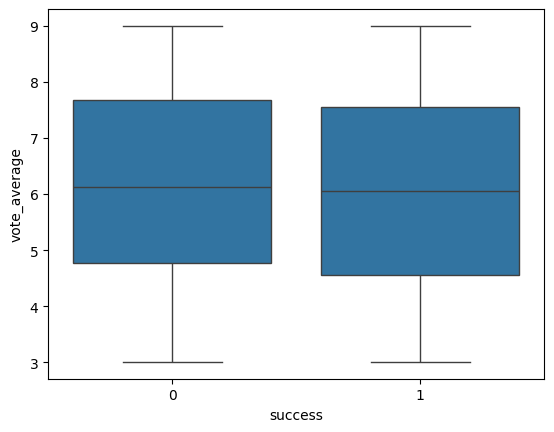

In [19]:
sns.boxplot(
    x='success',
    y='vote_average',
    data=df
)

Runtime vs Success

<Axes: xlabel='success', ylabel='runtime'>

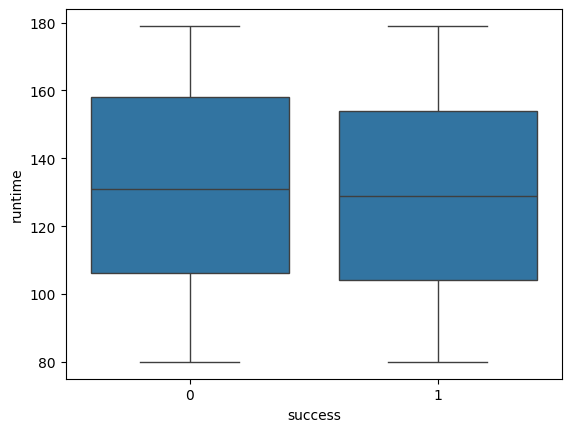

In [20]:
sns.boxplot(
    x='success',
    y='runtime',
    data=df
)

## Genre Analysis

Most Common Genres

<Axes: xlabel='genres'>

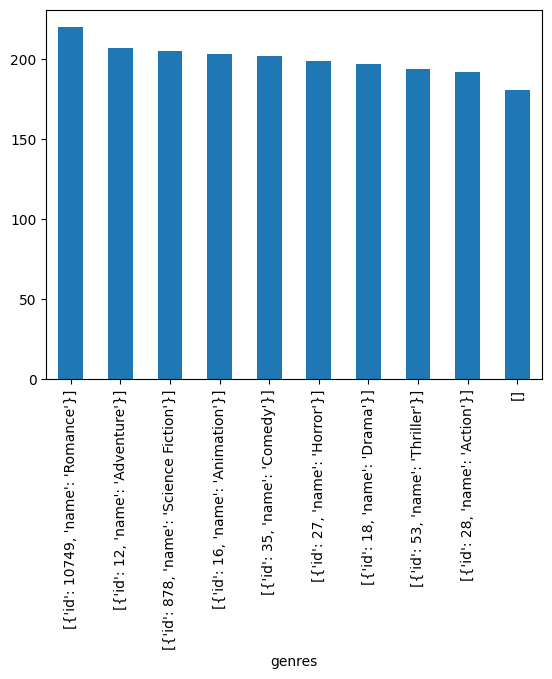

In [21]:

genre_count = (
    df['genres']
    .str.split('|')
    .explode()
    .value_counts()
)

genre_count.plot(kind='bar')

Most Successful Genres

<Axes: xlabel='genres'>

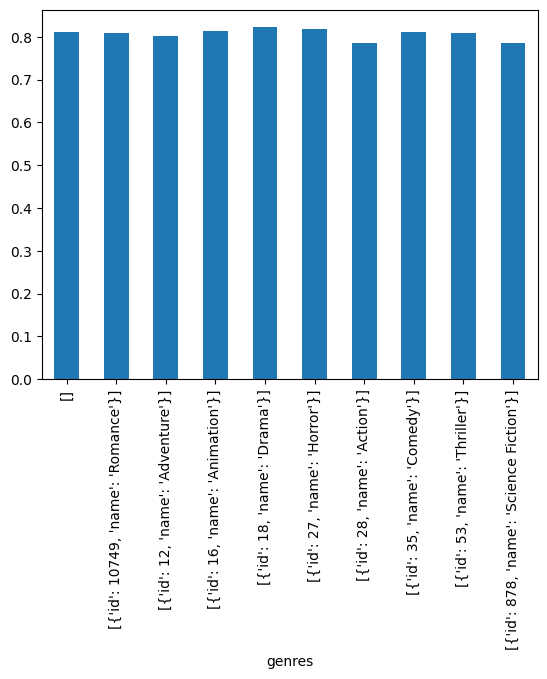

In [29]:

genre_success = (
    df
    .explode('genres')
    .groupby('genres')
    ['success']
    .mean()
)
genre_success.plot(kind='bar')

## Multivariate Analysis

Correlation Heatmap

<Axes: >

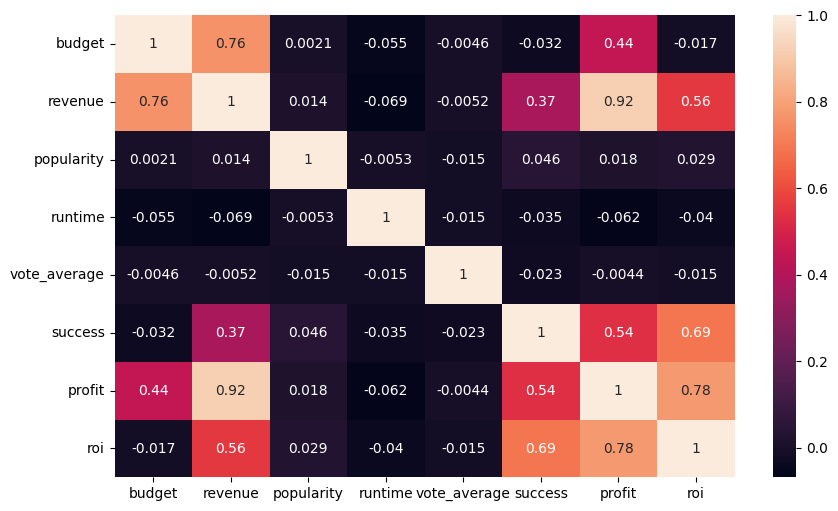

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(
        numeric_only=True
    ),
    annot=True
)

Pairplot

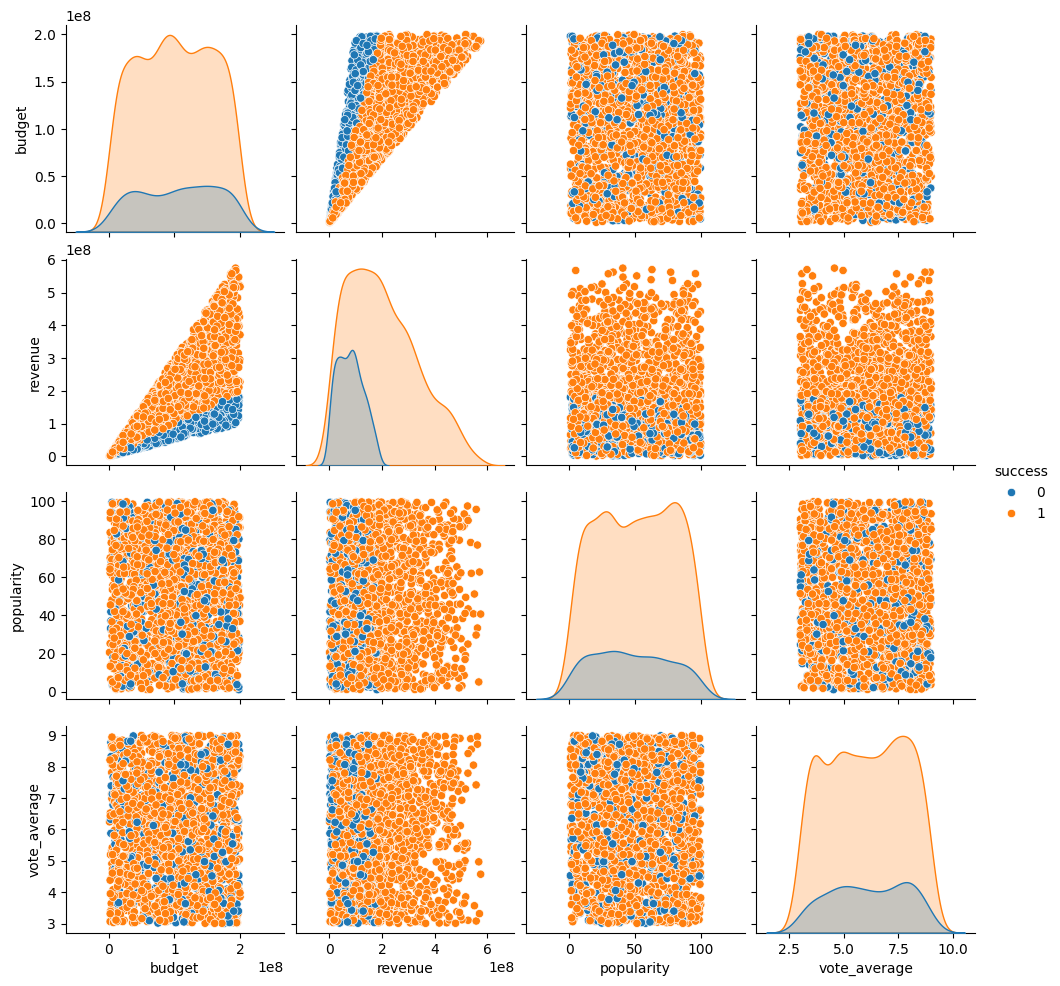

In [31]:

sns.pairplot(
    df[
        [
        'budget',
        'revenue',
        'popularity',
        'vote_average',
        'success'
        ]
    ],
    hue='success'
)

## Statistical Testing

T-Test

Hypothesis:

H0:

Popularity is same for successful and unsuccessful movies.

H1:

Popularity differs.

In [32]:
success = df[
    df.success==1
]['popularity']

failure = df[
    df.success==0
]['popularity']

ttest_ind(
    success,
    failure
)

TtestResult(statistic=2.064684104375536, pvalue=0.03908167189012841, df=1998.0)

Chi-Square Test

In [35]:
# Genre vs Success

genre_success_table = pd.crosstab(
    df['genres'],
    df['success']
)

chi2_contingency(genre_success_table)

Chi2ContingencyResult(statistic=1.7730811979406715, pvalue=0.9945690204257113, dof=9, expected_freq=array([[ 34.933, 146.067],
       [ 42.46 , 177.54 ],
       [ 39.951, 167.049],
       [ 39.179, 163.821],
       [ 38.021, 158.979],
       [ 38.407, 160.593],
       [ 37.056, 154.944],
       [ 38.986, 163.014],
       [ 37.442, 156.558],
       [ 39.565, 165.435]]))

In [32]:
from scipy.stats import ttest_ind

successful_popularity = df.loc[
    df["success"] == 1,
    "popularity"
]

unsuccessful_popularity = df.loc[
    df["success"] == 0,
    "popularity"
]

t_stat, p_value = ttest_ind(
    successful_popularity,
    unsuccessful_popularity,
    equal_var=False
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 2.0616702513558818
P-value: 0.03968244490792032


In [33]:
if p_value < 0.05:
    print("Reject H0")
    print("Popularity differs significantly.")
else:
    print("Fail to reject H0")
    print("No significant difference was found.")

Reject H0
Popularity differs significantly.


In [36]:
from scipy.stats import chi2_contingency

chi2, p_value, dof, expected = chi2_contingency(
    genre_success_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 1.7730811979406715
P-value: 0.9945690204257113
Degrees of freedom: 9
